In [ ]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, geometry, fem
import ufl
import gmsh
from dolfinx.io import gmsh as gmshio
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc
import basix.ufl
import matplotlib.pyplot as plt

Creation of Geometry

In [43]:
def create_square(h: float, L: float = 1.0) -> tuple[mesh.Mesh, ufl.Measure]:

    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("square")

    # --- Points du carré ---
    P1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, h)
    P2 = gmsh.model.geo.addPoint(L, 0.0, 0.0, h)
    P3 = gmsh.model.geo.addPoint(L, L, 0.0, h)
    P4 = gmsh.model.geo.addPoint(0.0, L, 0.0, h)

    # --- Lignes ---
    l1 = gmsh.model.geo.addLine(P1, P2)
    l2 = gmsh.model.geo.addLine(P2, P3)
    l3 = gmsh.model.geo.addLine(P3, P4)
    l4 = gmsh.model.geo.addLine(P4, P1)

    # --- Surface ---
    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    surface = gmsh.model.geo.addPlaneSurface([loop])

    gmsh.model.geo.synchronize()

    # --- Tags des bords ---
    gmsh.model.addPhysicalGroup(1, [l1], tag=1)
    gmsh.model.addPhysicalGroup(1, [l2], tag=2)
    gmsh.model.addPhysicalGroup(1, [l3], tag=3)
    gmsh.model.addPhysicalGroup(1, [l4], tag=4)

    # --- Tag du domaine ---
    gmsh.model.addPhysicalGroup(2, [surface], tag=10)

    # -------------------------------
    # 🔵 Taille du maillage (h = finesse)
    # -------------------------------
    gmsh.model.mesh.setSize(gmsh.model.getEntities(0), h)

    # --- Génération du maillage ---
    gmsh.model.mesh.generate(2)

    # --- Conversion vers Dolfinx ---
    data = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim=2)
    msh = data.mesh
    facet_tags = data.facet_tags

    gmsh.finalize()

    # -------------------------------
    # 🔵 AFFICHAGE DU MAILLAGE + TAGS
    # -------------------------------
    coords = msh.geometry.x
    conn = msh.topology.connectivity(2, 0)

    plt.figure(figsize=(6, 6))

    # Triangles
    for cell in range(conn.num_nodes):
        verts = conn.links(cell)
        pts = coords[verts]
        plt.fill(pts[:, 0], pts[:, 1], edgecolor="black", fill=False, linewidth=0.4)



    plt.axis("equal")
    plt.title(f"Maillage du carré (taille = {h})")
    plt.legend()
    plt.show()

    return msh, facet_tags



/tmp/ipykernel_3399/195039447.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


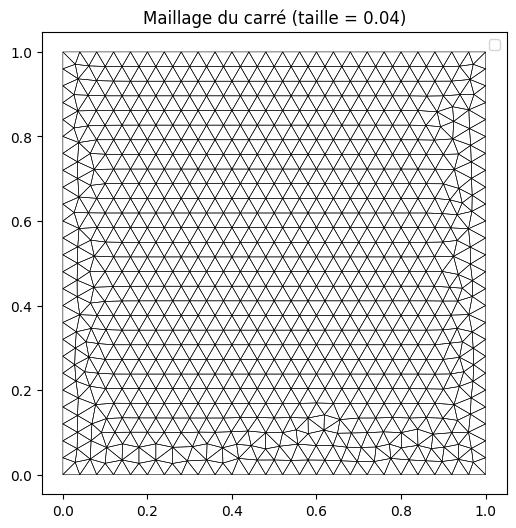

(<dolfinx.mesh.Mesh at 0x7d9aec9da540>,
 <dolfinx.mesh.MeshTags at 0x7d9aebf56300>)

In [52]:
create_square(0.04)

case study

In [ ]:
from dolfinx import mesh, geometry, fem
def evaluate_cook_primal(msh: mesh.Mesh,facet_tags: mesh.MeshTags, k: int, nu: float)->float:

    #We use the mesh to create the function space
    domain=msh
    element = basix.ufl.element("Lagrange", domain.topology.cell_name(), k, shape=(2,))
    V = fem.functionspace(domain, element)

    #We define the dirichlet boundary conditions on the side 1
    boundary_facets_1=facet_tags.find(1)  # use of the face tags create in the other function 
    dofs = fem.locate_dofs_topological(V, 1,boundary_facets_1)
    u_D = fem.Constant(domain, PETSc.ScalarType((0.0, 0.0)))
    bc = fem.dirichletbc(u_D, dofs,V) #create dirichlet boundary condition

    #create epsilon et sigma
    def epsilon(u):
        return 0.5*(ufl.grad(u)+ufl.grad(u).T)   #function of strain
    
    def sigma(u,lambda_,mu):
        return 2*mu*epsilon(u)+lambda_*ufl.tr(epsilon(u))*ufl.Identity(len(u)) #function of stress
    
    E=500
    u=ufl.TrialFunction(V)
    v=ufl.TestFunction(V)
    t=fem.Constant(domain,PETSc.ScalarType((0.0,20.0)))
    f=fem.Constant(domain,PETSc.ScalarType((0.0,0.0)))
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)

    #creation of Lame parameters
    lambda_= (E*nu)/((1+nu)*(1-2*nu))
    mu = E/(2*(1+nu))
   
    a=ufl.inner(sigma(u,lambda_,mu),epsilon(v))*ufl.dx #bilinear form
    L= ufl.dot(f,v)*ufl.dx + ufl.dot(t,v)*ds(3) #linear form

    problem = LinearProblem(a,L,bcs=[bc],petsc_options={"ksp_type": "preonly", "pc_type": "cholesky","pc_factor_mat_solver_type":"mumps"},petsc_options_prefix="membrane_") #creation of the problem

    result_primal_u=problem.solve()
    # Point A
    xA = np.array([[48.0, 60.0,0.0]], dtype=np.float64) #create a point of study A
    bb_tree = geometry.bb_tree(msh, msh.topology.dim) #create a box around the nodes to find faster the nodes
    cell_candidates = geometry.compute_collisions_points(bb_tree, xA) #find the box where is A
    cells = geometry.compute_colliding_cells(msh, cell_candidates, xA) #find exactly the cell where is the point A
    cell = cells.array[0] #extract the cell of the table
    uy_point_A = result_primal_u.eval(xA, np.array([cell]))[1] #extract the displacement in y axe in the point A

    ndofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs #determine the number of degrees of liberty

    return uy_point_A, ndofs